# Stereo Depth 실습 (KITTI Scene Flow 2015)

이 노트북은 두 대의 카메라로 촬영한 영상으로부터 **깊이(depth)** 를 추정하는 기본 원리를 배우고, KITTI 데이터셋을 사용해 직접 실습합니다.

**학습 목표**
1. 스테레오 비전의 기하학적 원리 이해 (시차 → 깊이)
2. KITTI 캘리브레이션 파일에서 카메라 파라미터 추출
3. OpenCV의 `StereoBM`, `StereoSGBM`으로 disparity map 계산
4. Disparity → Depth 변환 및 시각화
5. 3D 포인트 클라우드 복원

---
## 1. 이론 배경

### 1.1 사람은 어떻게 거리를 인지하는가?
두 눈이 약 6 cm 떨어져 있어, 같은 물체를 봐도 좌·우 망막에 맺히는 위치가 살짝 다릅니다. 이 **차이(parallax)** 가 클수록 가까운 물체이고, 작을수록 먼 물체입니다. 스테레오 카메라도 동일한 원리입니다.

### 1.2 스테레오 기하 (Rectified Stereo)
두 카메라가 **평행하게 정렬**되고 같은 평면 위에 있으면, 3D 점 $P=(X,Y,Z)$는 좌·우 영상에서 **같은 행(row)** 의 픽셀에 투영됩니다.

$$
u_L = f\frac{X}{Z} + c_x , \qquad u_R = f\frac{X-B}{Z} + c_x
$$

두 식의 차이를 **disparity**라 부르며:

$$
d = u_L - u_R = \frac{f \cdot B}{Z}
$$

따라서 깊이는:

$$
\boxed{\,Z = \frac{f \cdot B}{d}\,}
$$

- $f$ : 초점거리 (focal length, 픽셀 단위)
- $B$ : 두 카메라 사이 거리 (baseline, 미터)
- $d$ : disparity (픽셀)

**Q. 자동차에서 멀리 있는 차량 vs 가까운 보행자 — 누가 disparity가 더 클까요?**

### 1.3 Disparity는 어떻게 구하나?
왼쪽 영상의 한 픽셀과 **가장 비슷한** 오른쪽 영상의 픽셀을 같은 행(rectified의 장점!) 위에서 찾는 **블록 매칭(block matching)** 으로 구합니다. OpenCV는 두 가지를 제공합니다.
- `StereoBM` : 빠르고 단순 (SAD 기반)
- `StereoSGBM` : Semi-Global Matching, 더 정밀

### 1.4 KITTI 캘리브레이션
`calib_cam_to_cam/000xxx.txt`에는 rectified 영상의 **투영 행렬** $P_{rect}$가 들어 있습니다:

$$ P_{rect} = \begin{bmatrix} f & 0 & c_x & -f\cdot t_x \\ 0 & f & c_y & 0 \\ 0 & 0 & 1 & 0 \end{bmatrix} $$

KITTI는 4대의 카메라(`cam_0`~`cam_3`)가 있고, 본 실습에선 **컬러 좌측 `cam_2` / 컬러 우측 `cam_3`** 을 사용합니다.

baseline은 두 P 행렬의 마지막 열 차이로 구합니다:

$$ B = \frac{P_{02}[0,3] - P_{03}[0,3]}{f} $$

---
## 2. 환경 준비

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

print('OpenCV:', cv2.__version__)
print('NumPy :', np.__version__)

ROOT = Path('.').resolve()
CALIB_DIR = ROOT / 'data_scene_flow_calib' / 'training' / 'calib_cam_to_cam'
LEFT_DIR  = ROOT / 'data_scene_flow' / 'training' / 'image_2'     # 좌측 컬러 (cam_2)
RIGHT_DIR = ROOT / 'data_scene_flow' / 'training' / 'image_3'     # 우측 컬러 (cam_3)
GT_DIR    = ROOT / 'data_scene_flow' / 'training' / 'disp_occ_0'  # disparity GT (16-bit PNG)

# 본 실습에서는 10개 페어(000000 ~ 000009)만 사용합니다.
AVAILABLE_FRAMES = [f'{i:06d}' for i in range(10)]

for name, d in [('Calib', CALIB_DIR), ('Left', LEFT_DIR), ('Right', RIGHT_DIR), ('GT', GT_DIR)]:
    print(f'{name:5s} dir exists:', d.exists(), '->', d)

OpenCV: 4.13.0
NumPy : 1.24.4
Calib dir exists: True -> /home/ircv9/HYU-ECL3003/stereo_depth_tutorial/data_scene_flow_calib/training/calib_cam_to_cam
Left  dir exists: True -> /home/ircv9/HYU-ECL3003/stereo_depth_tutorial/data_scene_flow/training/image_2
Right dir exists: True -> /home/ircv9/HYU-ECL3003/stereo_depth_tutorial/data_scene_flow/training/image_3
GT    dir exists: True -> /home/ircv9/HYU-ECL3003/stereo_depth_tutorial/data_scene_flow/training/disp_occ_0


---
## 3. 캘리브레이션 파싱

KITTI의 calibration 파일은 `key: v1 v2 v3 ...` 형식의 텍스트입니다. 우리가 필요한 값은 `P_rect_02`, `P_rect_03` 두 줄입니다.

In [2]:
def read_kitti_calib(path):
    """KITTI calib_cam_to_cam 파일을 dict로 파싱."""
    calib = {}
    with open(path) as f:
        for line in f:
            if ':' not in line:
                continue
            key, val = line.split(':', 1)
            try:
                calib[key.strip()] = np.array([float(x) for x in val.split()])
            except ValueError:
                pass
    return calib

FRAME_ID = '000000'
calib = read_kitti_calib(CALIB_DIR / f'{FRAME_ID}.txt')

P2 = calib['P_rect_02'].reshape(3, 4)
P3 = calib['P_rect_03'].reshape(3, 4)

f_px   = P2[0, 0]                          # focal length (pixel)
cx, cy = P2[0, 2], P2[1, 2]                # principal point
baseline_m = (P2[0, 3] - P3[0, 3]) / f_px  # baseline (meter)

print(f'focal length f  = {f_px:.2f} px')
print(f'principal pt   = ({cx:.2f}, {cy:.2f})')
print(f'baseline B     = {baseline_m:.4f} m')

focal length f  = 721.54 px
principal pt   = (609.56, 172.85)
baseline B     = 0.5327 m


> **확인:** KITTI 스테레오 baseline은 약 **0.54 m** 입니다.

---
## 4. Stereo Pair 불러오기

image shape: (375, 1242, 3)


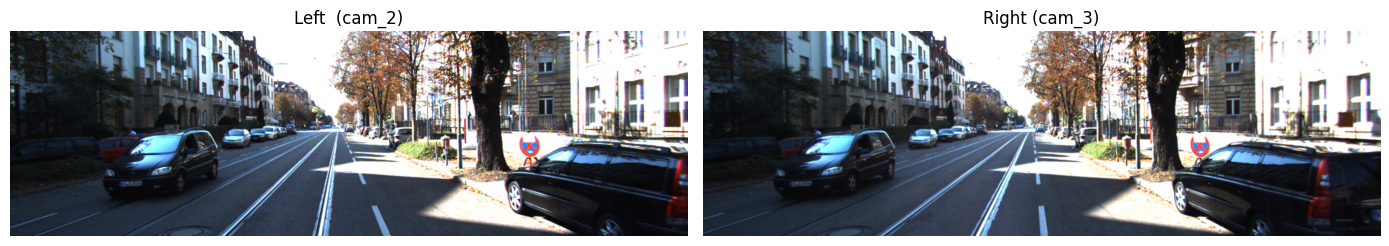

In [3]:
# 첫 프레임 (xxxxx_10.png가 stereo의 기준 프레임)
left_path  = LEFT_DIR  / f'{FRAME_ID}_10.png'
right_path = RIGHT_DIR / f'{FRAME_ID}_10.png'

assert left_path.exists()  and right_path.exists(), \
    f'이미지가 없습니다. data_scene_flow.zip 압축 해제 후 다시 실행하세요.\n  {left_path}\n  {right_path}'

left_bgr  = cv2.imread(str(left_path))
right_bgr = cv2.imread(str(right_path))
left_rgb  = cv2.cvtColor(left_bgr,  cv2.COLOR_BGR2RGB)
right_rgb = cv2.cvtColor(right_bgr, cv2.COLOR_BGR2RGB)
print('image shape:', left_rgb.shape)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].imshow(left_rgb);  ax[0].set_title('Left  (cam_2)');  ax[0].axis('off')
ax[1].imshow(right_rgb); ax[1].set_title('Right (cam_3)');  ax[1].axis('off')
plt.tight_layout(); plt.show()

### 4.1 Disparity 직접 확인하기
두 영상을 빨강/시안으로 합쳐 보면, 가까운 물체일수록 어긋남이 큽니다.

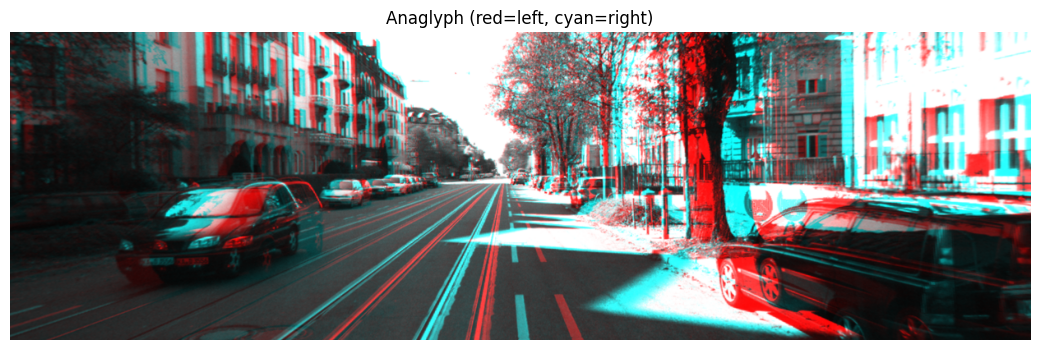

In [4]:
anaglyph = np.zeros_like(left_rgb)
anaglyph[..., 0] = cv2.cvtColor(left_rgb,  cv2.COLOR_RGB2GRAY)  # R = left
anaglyph[..., 1] = cv2.cvtColor(right_rgb, cv2.COLOR_RGB2GRAY)  # G = right
anaglyph[..., 2] = cv2.cvtColor(right_rgb, cv2.COLOR_RGB2GRAY)  # B = right

plt.figure(figsize=(14, 4))
plt.imshow(anaglyph); plt.title('Anaglyph (red=left, cyan=right)'); plt.axis('off'); plt.show()

---
## 5. Disparity 계산

### 5.1 StereoBM (Block Matching) — 빠름

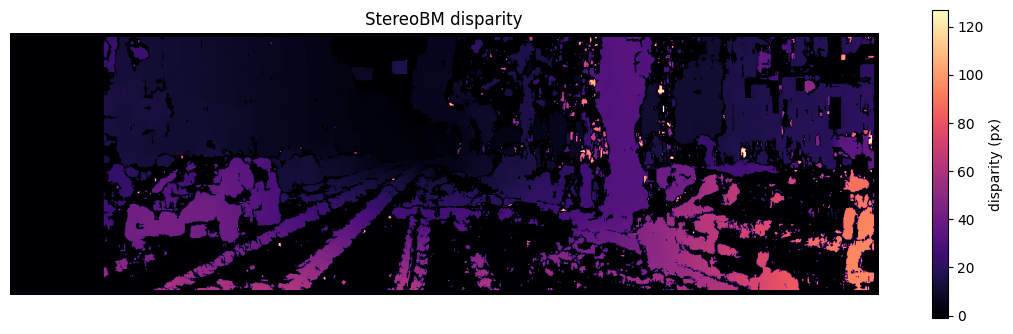

In [5]:
left_gray  = cv2.cvtColor(left_bgr,  cv2.COLOR_BGR2GRAY)
right_gray = cv2.cvtColor(right_bgr, cv2.COLOR_BGR2GRAY)

# numDisparities는 16의 배수, blockSize는 5~21 사이 홀수
stereo_bm = cv2.StereoBM_create(numDisparities=128, blockSize=15)
disp_bm = stereo_bm.compute(left_gray, right_gray).astype(np.float32) / 16.0  # OpenCV는 16배 정수로 반환

plt.figure(figsize=(14, 4))
plt.imshow(disp_bm, cmap='magma'); plt.colorbar(label='disparity (px)')
plt.title('StereoBM disparity'); plt.axis('off'); plt.show()

### 5.2 StereoSGBM (Semi-Global) — 더 정밀
Texture가 부족한 영역(도로면, 하늘 등)에서도 BM보다 안정적입니다.

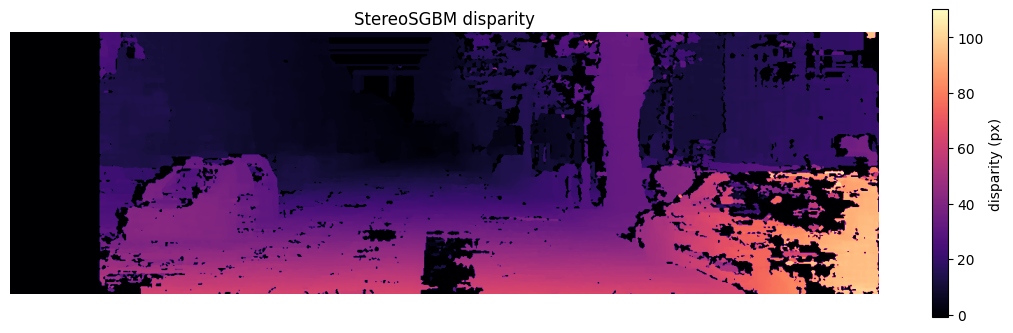

In [6]:
min_disp, num_disp, block = 0, 128, 5
stereo_sgbm = cv2.StereoSGBM_create(
    minDisparity      = min_disp,
    numDisparities    = num_disp,           # 16의 배수
    blockSize         = block,
    P1                = 8  * 3 * block**2,  # smoothness penalty (small change)
    P2                = 32 * 3 * block**2,  # smoothness penalty (large change)
    disp12MaxDiff     = 1,
    uniquenessRatio   = 10,
    speckleWindowSize = 100,
    speckleRange      = 32,
    mode              = cv2.STEREO_SGBM_MODE_SGBM_3WAY,
)
disp_sgbm = stereo_sgbm.compute(left_bgr, right_bgr).astype(np.float32) / 16.0

plt.figure(figsize=(14, 4))
plt.imshow(disp_sgbm, cmap='magma'); plt.colorbar(label='disparity (px)')
plt.title('StereoSGBM disparity'); plt.axis('off'); plt.show()

---
## 6. Disparity → Depth 변환
$Z = f \cdot B / d$ 를 적용합니다. disparity가 0 이하인 픽셀(매칭 실패)은 무한대로 두기 때문에 마스킹이 필요합니다.

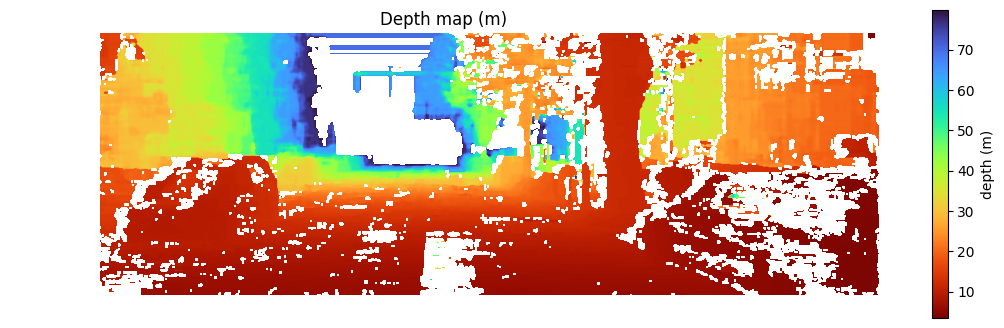

유효 픽셀 비율 : 72.2%
평균 깊이      : 23.45 m
중앙값         : 17.47 m


In [7]:
def disparity_to_depth(disp, f, B, max_depth=80.0):
    """disp(px) → depth(m). 유효하지 않은 값은 NaN."""
    depth = np.full(disp.shape, np.nan, dtype=np.float32)
    valid = disp > 0
    depth[valid] = (f * B) / disp[valid]
    depth[depth > max_depth] = np.nan
    return depth

depth_m = disparity_to_depth(disp_sgbm, f_px, baseline_m, max_depth=80.0)

plt.figure(figsize=(14, 4))
plt.imshow(depth_m, cmap='turbo_r'); plt.colorbar(label='depth (m)')
plt.title('Depth map (m)'); plt.axis('off'); plt.show()

print(f'유효 픽셀 비율 : {np.isfinite(depth_m).mean()*100:.1f}%')
print(f'평균 깊이      : {np.nanmean(depth_m):.2f} m')
print(f'중앙값         : {np.nanmedian(depth_m):.2f} m')

### 6.1 픽셀의 깊이 클릭으로 읽어 보기
이미지의 특정 좌표를 입력해 실제 거리를 확인합니다.

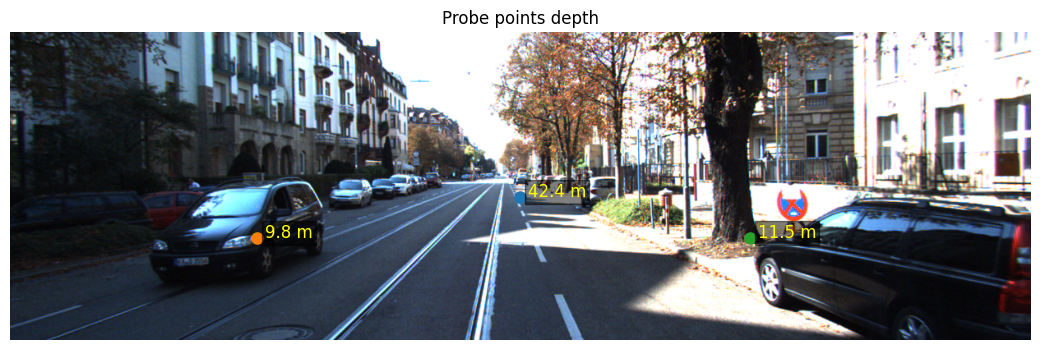

In [8]:
# (x, y) 픽셀 좌표를 지정하면 거리를 출력합니다.
probes = [(620, 200), (300, 250), (900, 250)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.imshow(left_rgb); ax.axis('off')
for (x, y) in probes:
    z = depth_m[y, x]
    ax.plot(x, y, 'o', markersize=8)
    ax.text(x+10, y, f'{z:.1f} m' if np.isfinite(z) else 'invalid',
            color='yellow', fontsize=12,
            bbox=dict(facecolor='black', alpha=0.5, pad=2))
plt.title('Probe points depth'); plt.show()

---
## 7. 3D 포인트 클라우드 복원
각 픽셀 $(u, v)$ 와 깊이 $Z$로부터 3D 좌표를 복원합니다:

$$
X = \frac{(u - c_x) \cdot Z}{f}, \quad Y = \frac{(v - c_y) \cdot Z}{f}, \quad Z = Z
$$

point count: 336412


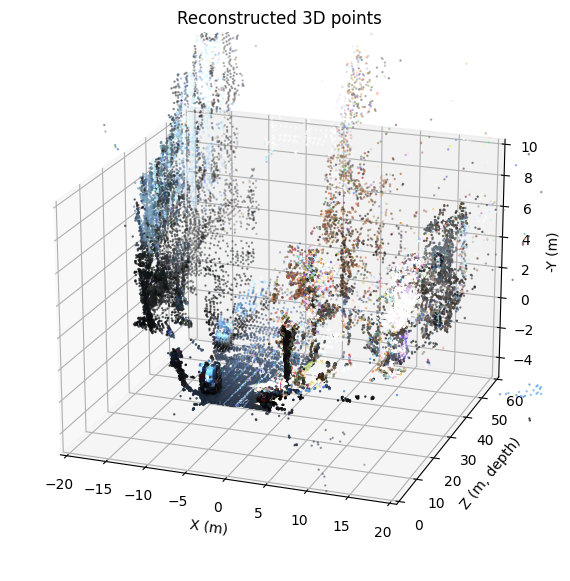

In [9]:
H, W = depth_m.shape
uu, vv = np.meshgrid(np.arange(W), np.arange(H))
X = (uu - cx) * depth_m / f_px
Y = (vv - cy) * depth_m / f_px
Z = depth_m

mask = np.isfinite(Z)
pts    = np.stack([X[mask], Y[mask], Z[mask]], axis=-1)
colors = left_rgb[mask] / 255.0
print('point count:', pts.shape[0])

# 다운샘플하여 시각화
step = max(1, pts.shape[0] // 40000)
p = pts[::step]; c = colors[::step]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(p[:, 0], p[:, 2], -p[:, 1], c=c, s=0.5)  # x=좌우, z=깊이, -y=위로
ax.set_xlabel('X (m)'); ax.set_ylabel('Z (m, depth)'); ax.set_zlabel('-Y (m)')
ax.set_xlim(-20, 20); ax.set_ylim(0, 60); ax.set_zlim(-5, 10)
ax.view_init(elev=20, azim=-70); plt.title('Reconstructed 3D points'); plt.show()

---
## 8. Ground Truth와 비교 (KITTI 평가)

KITTI는 LiDAR로 측정한 정답 disparity를 `disp_occ_0/` 폴더에 **16-bit PNG**로 제공합니다. 규약은 다음과 같습니다:
- 픽셀값 `v` → disparity `d = v / 256.0` (서브픽셀 정밀도)
- `v == 0` 인 픽셀은 **유효하지 않음**(LiDAR 측정 없음, 하늘 등)

이걸로 우리가 계산한 SGBM disparity의 품질을 정량 평가합니다.

### KITTI 공식 메트릭
- **EPE** (End-Point Error): $\;|d_{est} - d_{gt}|$ 의 평균 (px)
- **D1** (bad pixel rate): 다음 두 조건을 **동시에** 만족하면 "bad"로 분류한 픽셀의 비율
  - 절대오차 `> 3 px` **AND**
  - 상대오차 `> 5%` (즉 `|err| / d_gt > 0.05`)

KITTI 리더보드에서 SGBM 기준 D1은 약 8% 내외, 최신 딥러닝 모델은 ~1%대입니다.

GT shape         : (375, 1242)
GT valid ratio   : 19.1%
GT disparity 범위 : [4.62, 64.09] px


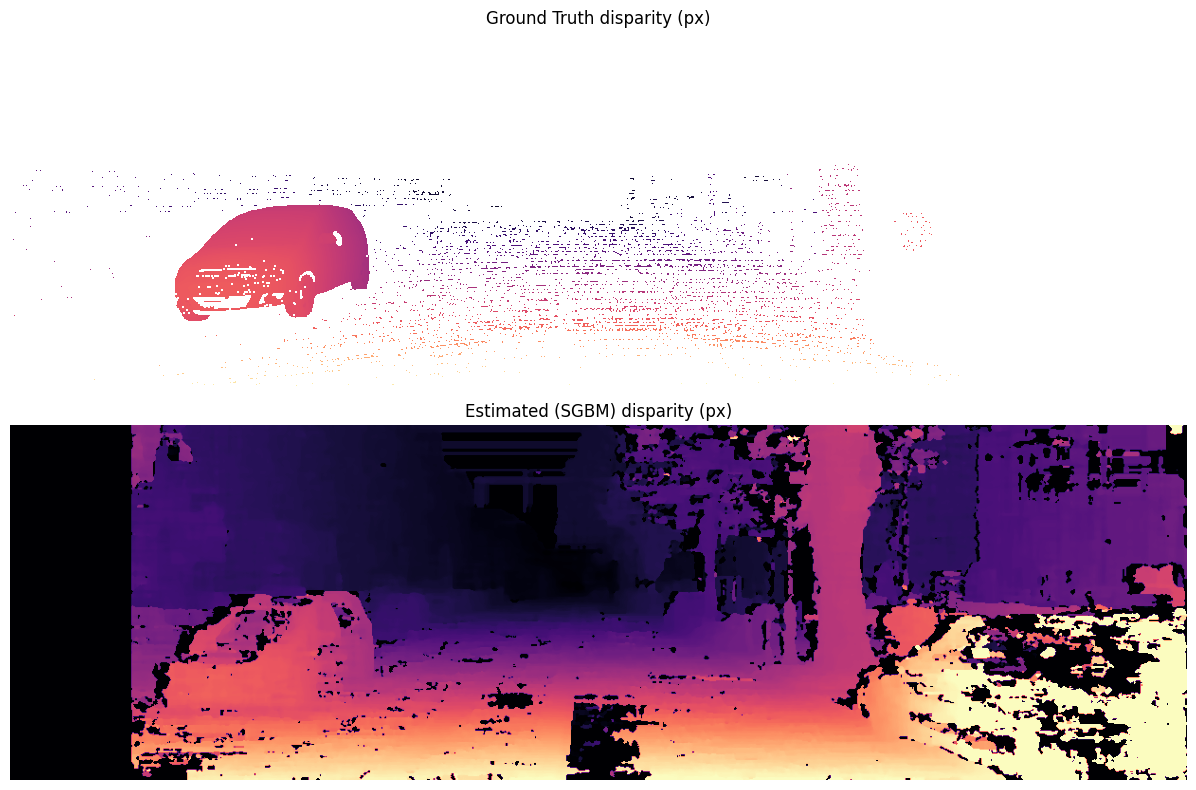

In [10]:
def load_kitti_disparity_gt(path):
    """KITTI disp_occ_0의 16-bit PNG → float disparity (px). 무효 픽셀은 NaN."""
    raw = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    assert raw is not None and raw.dtype == np.uint16, f'unexpected GT: {path}'
    disp_gt = raw.astype(np.float32) / 256.0
    disp_gt[raw == 0] = np.nan
    return disp_gt

gt_path = GT_DIR / f'{FRAME_ID}_10.png'
disp_gt = load_kitti_disparity_gt(gt_path)

print(f'GT shape         : {disp_gt.shape}')
print(f'GT valid ratio   : {np.isfinite(disp_gt).mean()*100:.1f}%')
print(f'GT disparity 범위 : [{np.nanmin(disp_gt):.2f}, {np.nanmax(disp_gt):.2f}] px')

fig, ax = plt.subplots(2, 1, figsize=(14, 8))
vmax = float(np.nanmax(disp_gt))
ax[0].imshow(disp_gt,   cmap='magma', vmin=0, vmax=vmax)
ax[0].set_title('Ground Truth disparity (px)'); ax[0].axis('off')
ax[1].imshow(disp_sgbm, cmap='magma', vmin=0, vmax=vmax)
ax[1].set_title('Estimated (SGBM) disparity (px)'); ax[1].axis('off')
plt.tight_layout(); plt.show()

### 8.1 오차 맵과 정량 지표
GT가 유효한 픽셀에서만 SGBM 결과와 비교합니다. SGBM이 매칭 실패로 음수를 반환한 픽셀도 제외합니다.

EPE           : 1.263 px
D1 (bad px)   : 6.53%
유효 비교 픽셀 : 76,494 (16.4%)


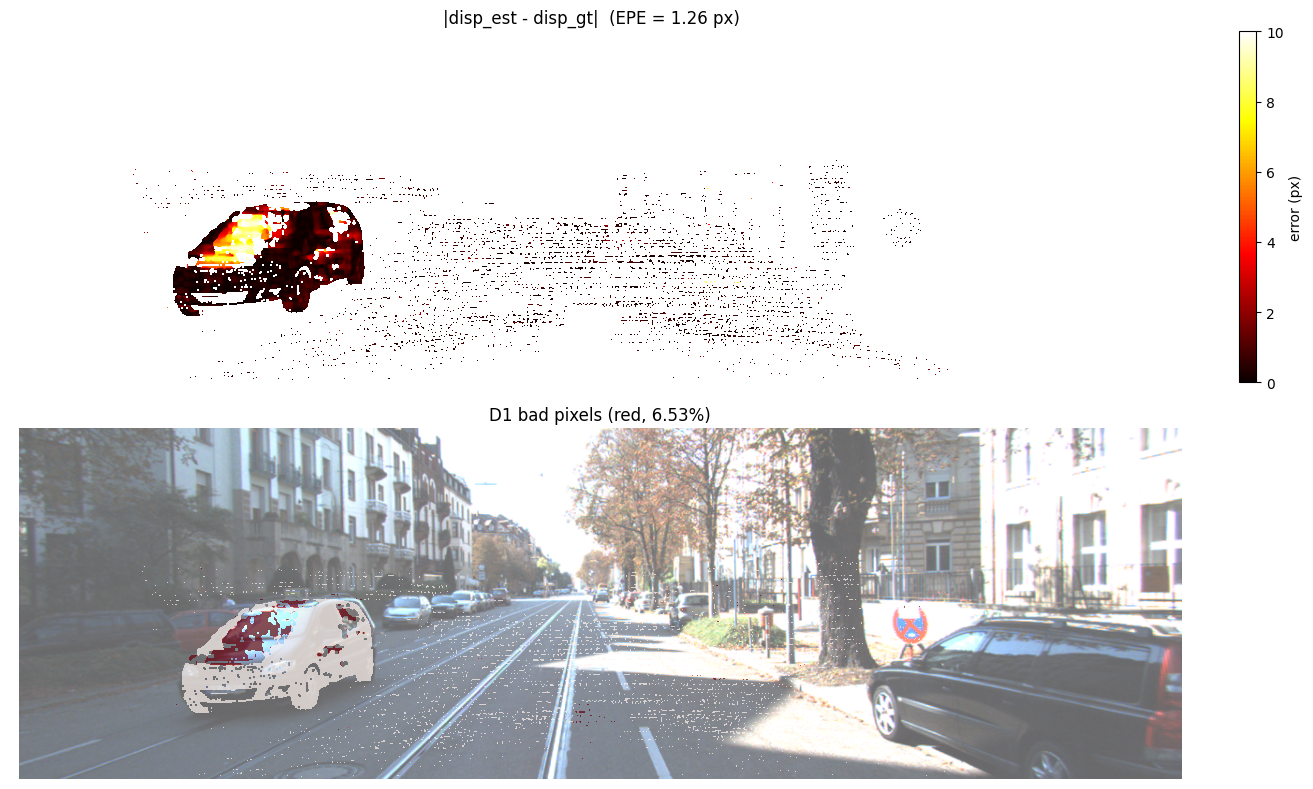

In [11]:
def evaluate_disparity(disp_est, disp_gt, abs_thr=3.0, rel_thr=0.05):
    """KITTI 평가 메트릭. 유효 픽셀에서 EPE와 D1(bad pixel rate)을 계산."""
    valid = np.isfinite(disp_gt) & (disp_est > 0)
    err   = np.abs(disp_est - disp_gt)
    epe   = float(err[valid].mean())
    bad   = (err > abs_thr) & (err > rel_thr * disp_gt)
    d1    = float(bad[valid].mean()) * 100.0  # %
    return epe, d1, err, valid, bad

epe, d1, err, valid, bad = evaluate_disparity(disp_sgbm, disp_gt)
print(f'EPE           : {epe:.3f} px')
print(f'D1 (bad px)   : {d1:.2f}%')
print(f'유효 비교 픽셀 : {valid.sum():,} ({valid.mean()*100:.1f}%)')

# 시각화: (1) 절대 오차 (2) bad-pixel 마스크
err_vis = np.where(valid, err, np.nan)
bad_vis = np.where(valid, bad.astype(np.float32), np.nan)

fig, ax = plt.subplots(2, 1, figsize=(14, 8))
im0 = ax[0].imshow(err_vis, cmap='hot', vmin=0, vmax=10)
ax[0].set_title(f'|disp_est - disp_gt|  (EPE = {epe:.2f} px)'); ax[0].axis('off')
plt.colorbar(im0, ax=ax[0], fraction=0.02, label='error (px)')

ax[1].imshow(left_rgb, alpha=0.6)
ax[1].imshow(bad_vis, cmap='Reds', vmin=0, vmax=1, alpha=0.7)
ax[1].set_title(f'D1 bad pixels (red, {d1:.2f}%)'); ax[1].axis('off')
plt.tight_layout(); plt.show()

### 8.2 10개 페어 전체 평가
보유한 10개 스테레오 페어에 동일한 SGBM 파이프라인을 돌려 EPE / D1 평균을 구합니다.

In [12]:
results = []
for fid in AVAILABLE_FRAMES:
    L = cv2.imread(str(LEFT_DIR  / f'{fid}_10.png'))
    R = cv2.imread(str(RIGHT_DIR / f'{fid}_10.png'))
    if L is None or R is None:
        print(f'[skip] {fid}: image missing'); continue
    disp = stereo_sgbm.compute(L, R).astype(np.float32) / 16.0
    gt   = load_kitti_disparity_gt(GT_DIR / f'{fid}_10.png')
    e, d, *_ = evaluate_disparity(disp, gt)
    results.append((fid, e, d))
    print(f'  frame {fid}:  EPE = {e:5.2f} px   D1 = {d:5.2f}%')

epe_avg = np.mean([r[1] for r in results])
d1_avg  = np.mean([r[2] for r in results])
print('-' * 40)
print(f'  AVERAGE   :  EPE = {epe_avg:5.2f} px   D1 = {d1_avg:5.2f}%')

  frame 000000:  EPE =  1.26 px   D1 =  6.53%
  frame 000001:  EPE =  0.99 px   D1 =  3.39%
  frame 000002:  EPE =  2.44 px   D1 = 11.89%
  frame 000003:  EPE =  1.81 px   D1 =  8.23%
  frame 000004:  EPE =  2.48 px   D1 = 12.19%
  frame 000005:  EPE =  2.12 px   D1 = 10.33%
  frame 000006:  EPE =  2.71 px   D1 = 18.55%
  frame 000007:  EPE =  0.85 px   D1 =  3.11%
  frame 000008:  EPE =  0.83 px   D1 =  2.22%
  frame 000009:  EPE =  0.83 px   D1 =  1.67%
----------------------------------------
  AVERAGE   :  EPE =  1.63 px   D1 =  7.81%


### 8.3 WLS 필터 후처리 (Weighted Least Squares)

SGBM 결과는 텍스처가 부족한 영역에서 노이즈가 많고 경계가 흐릿합니다. **WLS 필터**는 좌측 영상을 가이드로 사용하는 edge-aware filter로, 다음 효과를 줍니다.
- 경계는 살리면서 평탄 영역의 노이즈를 매끄럽게 다듬음
- 좌·우 disparity의 불일치(occlusion)를 자동으로 채워줌

> 참고: SGBM, BM, WLS는 모두 **학습이 아닌 결정론적(deterministic) 전통 알고리즘**입니다. 학습 데이터·GPU가 필요 없고 파라미터는 사람이 설정합니다. 학습 기반은 PSMNet, RAFT-Stereo 등 별도 모델입니다.

WLS 핵심 파라미터:
- `lambda` — smoothness 강도 (보통 8000)
- `sigmaColor` — 색상 유사도 기준 (보통 1.5)

OpenCV의 `ximgproc` (contrib 모듈) 필요:
```bash
pip install opencv-contrib-python
```

In [13]:
# WLS 필터(cv2.ximgproc) 사용을 위해 opencv-contrib-python을 설치합니다.
# 이미 설치돼 있으면 그대로 통과합니다. 설치 직후에는 커널 재시작이 필요할 수 있습니다.
import sys, importlib

need_install = True
if importlib.util.find_spec('cv2') is not None:
    import cv2 as _cv2_probe
    need_install = not hasattr(_cv2_probe, 'ximgproc')

if need_install:
    print('Installing opencv-contrib-python into', sys.executable)
    !{sys.executable} -m pip install -q opencv-contrib-python
    print('설치 완료. 셀 위쪽 import cv2가 캐시되어 있다면 커널을 재시작하고 다시 실행하세요.')
else:
    print('cv2.ximgproc 사용 가능 ✓')

cv2.ximgproc 사용 가능 ✓


[before WLS] EPE = 1.26 px   D1 = 6.53%
[after  WLS] EPE = 1.33 px   D1 = 9.59%


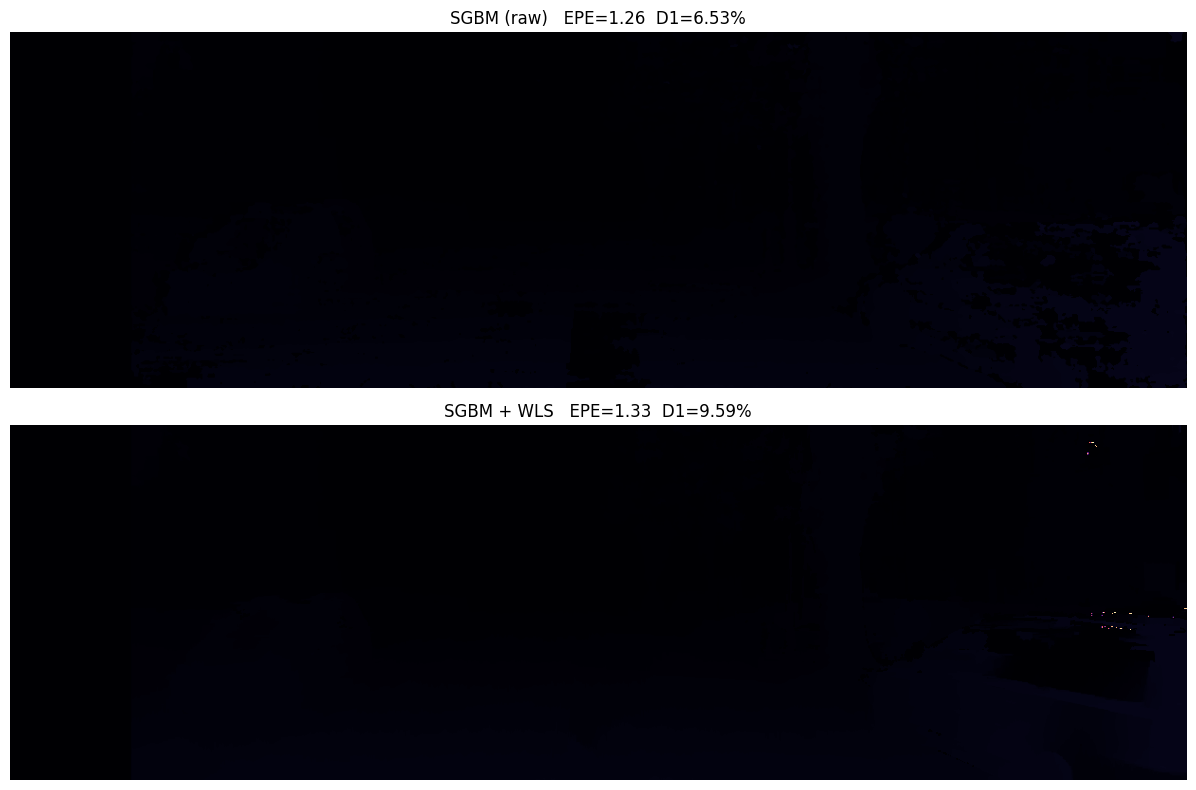

In [14]:
def apply_wls_filter(left_bgr, right_bgr, left_matcher,
                     lmbda=8000.0, sigma=1.5):
    """SGBM + WLS 후처리. 학습 없이 결정론적.
    Returns: disp_filtered (float, px), disp_raw (float, px)
    """
    assert hasattr(cv2, 'ximgproc'), (
        'opencv-contrib-python이 필요합니다.\n'
        '  pip install opencv-contrib-python'
    )

    # 좌·우 disparity 모두 필요. 우측 matcher는 left_matcher와 짝을 이룸.
    right_matcher = cv2.ximgproc.createRightMatcher(left_matcher)

    disp_left  = left_matcher.compute(left_bgr,  right_bgr)   # int16, 16x fixed-point
    disp_right = right_matcher.compute(right_bgr, left_bgr)

    wls = cv2.ximgproc.createDisparityWLSFilter(matcher_left=left_matcher)
    wls.setLambda(lmbda)
    wls.setSigmaColor(sigma)

    # filter는 좌측 영상을 가이드로 사용
    disp_filtered_int = wls.filter(disp_left, left_bgr, disparity_map_right=disp_right)

    return disp_filtered_int.astype(np.float32) / 16.0, disp_left.astype(np.float32) / 16.0


try:
    disp_wls, _ = apply_wls_filter(left_bgr, right_bgr, stereo_sgbm,
                                   lmbda=8000.0, sigma=1.5)
    epe_w, d1_w, *_ = evaluate_disparity(disp_wls, disp_gt)
    print(f'[before WLS] EPE = {epe:.2f} px   D1 = {d1:.2f}%')
    print(f'[after  WLS] EPE = {epe_w:.2f} px   D1 = {d1_w:.2f}%')

    fig, ax = plt.subplots(2, 1, figsize=(14, 8))
    vmax = max(np.nanmax(disp_sgbm), np.nanmax(disp_wls))
    ax[0].imshow(disp_sgbm, cmap='magma', vmin=0, vmax=vmax)
    ax[0].set_title(f'SGBM (raw)   EPE={epe:.2f}  D1={d1:.2f}%'); ax[0].axis('off')
    ax[1].imshow(disp_wls,  cmap='magma', vmin=0, vmax=vmax)
    ax[1].set_title(f'SGBM + WLS   EPE={epe_w:.2f}  D1={d1_w:.2f}%'); ax[1].axis('off')
    plt.tight_layout(); plt.show()
except AssertionError as e:
    print(e)
    print('아래 셀은 설치 후 다시 실행하면 됩니다.')

### 8.4 Densification — FBS / Inpaint & Guided Filter 비교

SGBM은 매칭 실패 픽셀을 `-1`로 남겨 결과가 **sparse**합니다. 후처리로 dense하게 만드는 방법을 비교합니다.

| 방법 | 원리 | hole filling | refinement |
|---|---|---|---|
| **WLS** | edge-aware iterative smoothing | △ (부분) | ◯ |
| **Guided Filter** | 좌영상을 가이드로 한 linear filter | X | ◎ |
| **Fast Bilateral Solver (FBS)** | confidence-weighted bilateral solver | ◎ | ◎ |
| **Inpaint + Guided** | Telea inpaint로 hole 채우고 guided로 정제 | ◎ | ◎ |

**핵심**: FBS는 `confidence map`(SGBM 유효=1)을 명시적으로 받아 신뢰 픽셀은 보존하고 무효 픽셀만 채웁니다. 다만 **`opencv-contrib-python` wheel은 Eigen 없이 빌드되어 FBS 함수가 비활성화**된 경우가 많습니다. 그 경우 `cv2.inpaint(Telea)` 으로 hole을 먼저 채우고 guided filter로 다듬는 조합이 거의 동등한 결과를 줍니다.

아래 셀에서 시간 / density / EPE / D1을 동시에 비교합니다. FBS가 빌드에 없으면 자동으로 skip 됩니다.

[skip] FBS 사용 불가: OpenCV(4.13.0) /io/opencv_contrib/modules/ximgproc/src/fbs_filter.cpp:632: error: (-213:The function/feature is not implemented) createFastBilateralSolverFilter : needs to be compiled with EIGEN in function 'createFastBilateralSolverFilter'
       opencv-contrib-python wheel이 Eigen 없이 빌드된 경우입니다.
       Inpaint + Guided로 대체합니다.

method                           time      density        EPE        D1
----------------------------------------------------------------------------------
SGBM (raw)               time=  186.2 ms   density= 89.3%   EPE= 2.43 px   D1=10.46%
SGBM + WLS *             time=  344.7 ms   density= 86.2%   EPE= 1.26 px   D1= 8.57%
SGBM + GuidedFilter      time=   64.9 ms   density= 91.0%   EPE= 2.56 px   D1=16.24%
SGBM + Inpaint+Guided    time=   92.3 ms   density=100.0%   EPE= 2.35 px   D1=15.97%
SGBM + FBS               (unavailable)
----------------------------------------------------------------------------------
* WLS 시간은 좌·우 SGBM 2회 + filter 합계 (

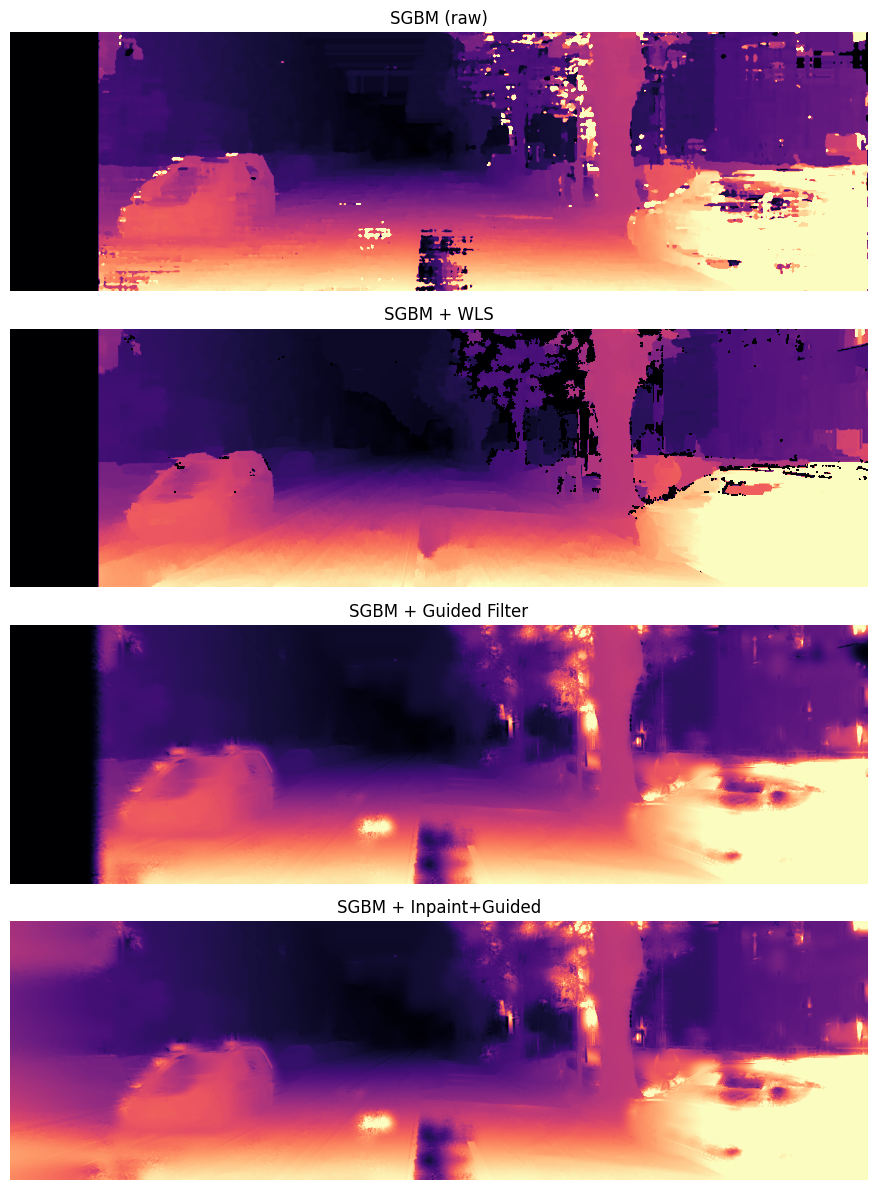

In [15]:
import time

def measure(fn):
    """fn 실행 시간(ms)과 결과를 반환."""
    t0 = time.perf_counter()
    out = fn()
    return out, (time.perf_counter() - t0) * 1000.0


def run_fbs(disp_src, guide_bgr,
            sigma_spatial=8, sigma_luma=8, sigma_chroma=8,
            lam=128.0, num_iter=25):
    """Fast Bilateral Solver — Eigen 필요. 미지원 빌드면 NotImplementedError."""
    conf = (disp_src > 0).astype(np.float32)
    src  = np.where(disp_src > 0, disp_src, 0).astype(np.float32)
    fbs  = cv2.ximgproc.createFastBilateralSolverFilter(
        guide=guide_bgr,
        sigma_spatial=sigma_spatial, sigma_luma=sigma_luma, sigma_chroma=sigma_chroma,
        lambda_=lam, num_iter=num_iter, max_tol=1e-5)
    return fbs.filter(src, conf)


def run_guided(disp_src, guide_bgr, radius=8, eps=1e-3):
    """Guided filter — edge-aware refinement (hole filling 능력 없음)."""
    src = np.where(disp_src > 0, disp_src, 0).astype(np.float32)
    return cv2.ximgproc.guidedFilter(guide=guide_bgr, src=src,
                                     radius=radius, eps=eps)


def run_inpaint_densify(disp_src, inpaint_radius=5, method=cv2.INPAINT_TELEA):
    """cv2.inpaint으로 hole만 채움 (Eigen 불필요, FBS의 실용적 대체).
    8-bit inpaint이므로 disparity를 [0,255]로 스케일했다가 복원합니다."""
    invalid = ~(disp_src > 0)
    if not invalid.any():
        return disp_src.copy()
    valid_max = float(disp_src[~invalid].max())
    scale = 255.0 / max(valid_max, 1.0)
    disp_u8 = np.clip(disp_src * scale, 0, 255).astype(np.uint8)
    mask    = invalid.astype(np.uint8)
    filled  = cv2.inpaint(disp_u8, mask, inpaint_radius, method)
    out = disp_src.copy()
    out[invalid] = filled[invalid].astype(np.float32) / scale
    return out


def run_inpaint_plus_guided(disp_src, guide_bgr,
                            inpaint_radius=5, gf_radius=8, gf_eps=1e-3):
    """FBS의 실용적 대체: inpaint로 채우고 guided filter로 정제."""
    filled = run_inpaint_densify(disp_src, inpaint_radius)
    return cv2.ximgproc.guidedFilter(guide=guide_bgr,
                                     src=filled.astype(np.float32),
                                     radius=gf_radius, eps=gf_eps)


# --- 시간 측정 ---
disp_raw, t_sgbm = measure(lambda: stereo_sgbm.compute(left_bgr, right_bgr).astype(np.float32) / 16.0)
(disp_wls2, _), t_wls = measure(lambda: apply_wls_filter(left_bgr, right_bgr, stereo_sgbm))
disp_gf,  t_gf  = measure(lambda: run_guided(disp_raw, left_bgr))
disp_ip,  t_ip  = measure(lambda: run_inpaint_plus_guided(disp_raw, left_bgr))

# FBS는 Eigen 의존성 — 실패 시 graceful skip
disp_fbs, t_fbs = None, None
try:
    disp_fbs, t_fbs = measure(lambda: run_fbs(disp_raw, left_bgr))
except cv2.error as e:
    print('[skip] FBS 사용 불가:', str(e).splitlines()[0])
    print('       opencv-contrib-python wheel이 Eigen 없이 빌드된 경우입니다.')
    print('       Inpaint + Guided로 대체합니다.\n')


def report(name, disp, t_ms):
    if disp is None:
        print(f'{name:24s} (unavailable)')
        return
    valid = np.isfinite(disp_gt) & (disp > 0)
    err   = np.abs(disp - disp_gt)
    epe   = err[valid].mean()         if valid.any() else float('nan')
    bad   = (err > 3) & (err > 0.05 * disp_gt)
    d1    = bad[valid].mean() * 100   if valid.any() else float('nan')
    dens  = (disp > 0).mean() * 100
    print(f'{name:24s} time={t_ms:7.1f} ms   density={dens:5.1f}%   EPE={epe:5.2f} px   D1={d1:5.2f}%')

print(f'{"method":24s} {"time":>12s}   {"density":>10s}   {"EPE":>8s}   {"D1":>7s}')
print('-' * 82)
report('SGBM (raw)',          disp_raw,  t_sgbm)
report('SGBM + WLS *',        disp_wls2, t_wls)
report('SGBM + GuidedFilter', disp_gf,   t_gf)
report('SGBM + Inpaint+Guided', disp_ip, t_ip)
report('SGBM + FBS',          disp_fbs,  t_fbs)
print('-' * 82)
print('* WLS 시간은 좌·우 SGBM 2회 + filter 합계 (다른 후처리는 단독 시간).')


# --- 시각화 ---
vmax = float(np.nanmax(disp_gt))
methods = [
    ('SGBM (raw)',            disp_raw),
    ('SGBM + WLS',            disp_wls2),
    ('SGBM + Guided Filter',  disp_gf),
    ('SGBM + Inpaint+Guided', disp_ip),
]
if disp_fbs is not None:
    methods.append(('SGBM + FBS', disp_fbs))

fig, ax = plt.subplots(len(methods), 1, figsize=(14, 3.0 * len(methods)))
for a, (name, d) in zip(ax, methods):
    a.imshow(d, cmap='magma', vmin=0, vmax=vmax)
    a.set_title(name); a.axis('off')
plt.tight_layout(); plt.show()

---
## 9. 학생 실습 문제

### Exercise 1 — 파라미터 튜닝
`StereoSGBM`의 `blockSize`, `numDisparities`, `uniquenessRatio`를 바꿔 가며 disparity가 어떻게 변하는지 비교하세요. 8.1의 EPE / D1로 정량 비교까지 해 보세요.
- block을 키우면? 작게 하면?
- numDisparities를 줄이면 가까운 물체가 어떻게 보이나요?

### Exercise 2 — 다른 프레임에 적용
본 실습 폴더에는 `000000` ~ `000009` 10개 페어가 있습니다. `FRAME_ID`를 바꿔(예: `'000003'`, `'000007'`) 동일한 파이프라인을 돌려 보세요. **캘리브레이션도 프레임마다 다르므로 반드시 다시 불러와야 합니다.**

### Exercise 3 — Sub-pixel 정확도
`StereoSGBM.compute()`가 반환하는 정수값을 16으로 나누는 이유는? (`fixed-point` 검색)

### Exercise 4 — Depth 정확도 분석
다음 식을 유도하고, 거리가 멀어질수록 깊이 오차가 어떻게 증가하는지 그래프로 그려 보세요:
$$ \Delta Z = \frac{Z^2}{f \cdot B} \, \Delta d $$
*(힌트: $Z = fB/d$를 $d$로 미분)*

### Exercise 5 — WLS 파라미터 튜닝
8.3의 `lmbda`(1000 ~ 16000)와 `sigma`(0.5 ~ 3.0)를 그리드 탐색하여 10개 페어 평균 D1이 가장 낮은 조합을 찾으세요. 결과를 표로 정리해 보세요.

### Exercise 6 — 좌·우 일관성 검사
왼쪽 기준 disparity와 오른쪽 기준 disparity를 모두 구해, 두 결과가 일치하지 않는 픽셀을 occlusion(가려짐)으로 마스킹하세요. (힌트: 8.3 코드에 `right_matcher`가 이미 등장합니다)

---
## 10. 요약

| 단계 | 핵심 |
|---|---|
| 캘리브레이션 | $f$, $B$ 추출 (`P_rect_02`, `P_rect_03`) |
| Disparity 계산 | Rectified 영상에서 행 단위 블록 매칭 |
| Depth 변환 | $Z = fB/d$ |
| 3D 복원 | 픽셀 좌표와 $Z$로부터 $(X, Y, Z)$ |
| 평가 | EPE, D1 (`disp_occ_0` GT와 비교) |

**한계**: 무텍스처 영역, 반사·투명, 가려짐(occlusion), 먼 거리에서 큰 오차. 최신 연구는 딥러닝 기반(`PSMNet`, `RAFT-Stereo`)으로 이를 개선합니다.